# SD Attention-Guided Editing

Interactive notebook for testing and showcasing a single edit.  
Settings are loaded from `config.ini`.

**Workflow:**
1. Load config + model
2. Specify image / subject / edit prompt
3. Run DDIM inversion
4. Inspect the base mask
5. Edit (Pass 1)
6. Polish (Pass 2, if enabled)
7. Final comparison

## Setup

In [1]:
import sys, os, configparser
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Project root must be on the path
PROJECT_ROOT = os.path.abspath("")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from sd_editing import (
    load_sd15_edit_pipe,
    load_image_rgb,
    ddim_invert_store,
    reconstruct_ddim_with_attention_restoration,
)
from sd_editing.masks import build_base_mask_from_inversion_attn
from sd_editing.sam_mask import load_grounded_sam

print("Imports OK")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU (this will be slow)")

Imports OK
GPU: NVIDIA GeForce GTX 1070  |  VRAM: 8.5 GB


In [14]:
# ── Config helpers (mirrors main.py) ──────────────────────────────────────────
def _parse_tuple_of_strings(value):
    return tuple(p.strip() for p in value.split(",") if p.strip())

def _parse_float_pair(value):
    a, b = value.split(",")
    return (float(a.strip()), float(b.strip()))

CFG_PATH = "config.ini"
cfg = configparser.ConfigParser()
cfg.read(CFG_PATH)

MODEL   = cfg["model"]
G       = cfg["generation"]
P1      = cfg["pass1"]
P2      = cfg["pass2"]
SAM_CFG = cfg["sam"] if "sam" in cfg else {}

print(f"Config: '{CFG_PATH}'")
print(f"  model          = {MODEL['name']}")
print(f"  device         = {MODEL['device']}")
print(f"  steps          = {G['num_inference_steps']}")
print(f"  input_size     = {G['input_size']}")
print(f"  attention_res  = {G['attention_res']}")
print(f"  allowed_places = {G['allowed_places']}")
print(f"  base_mask_src  = {G['base_mask_source']}")
print(f"  pass2.enabled  = {P2['enabled']}")

Config: 'config.ini'
  model          = runwayml/stable-diffusion-v1-5
  device         = cuda
  steps          = 50
  input_size     = 512
  attention_res  = 32
  allowed_places = up
  base_mask_src  = sam
  pass2.enabled  = true


---
## ✏️  Parameters — edit this cell

Define paths and override settings.

In [18]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║               EDIT THESE PARAMETERS                              ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Input image ────────────────────────────────────────────────────
IMAGE_PATH = "input_data/images_dreambooth/cat/01.jpg"

# ── Subject description ────────────────────────────────────────────
#   Used to build the inversion prompt:  "photo of a {SUBJECT_DESCRIPTION}"
#   and to resolve which attention-map tokens to localize.
SUBJECT_DESCRIPTION = "beige cat"
TARGET_TOKENS       = ["cat"]      # must appear in inversion prompt + edit prompt

# ── Editing prompt ─────────────────────────────────────────────────
# {} is replaced with SUBJECT_DESCRIPTION
EDIT_PROMPT = "a photo of a {} sitting in the snow"

# ── Optional config overrides (None → use config.ini value) ────────
OVERRIDE = {
    # "base_mask_source":   "attention",  # "attention" | "sam"
    # "guidance_scale":     7.5,
    # "eta":                1.0,
    # "transmission_alpha": 1.0,
    # "initial_noise_beta": 0.75,
}

# ── Output base directory ──────────────────────────────────────────
OUTPUT_BASE = "output_notebook"

# ═══════════════════════════════════════════════════════════════════

# Resolve {} placeholder (same convention as batch.py)
EDIT_PROMPT = EDIT_PROMPT.format(SUBJECT_DESCRIPTION) if "{}" in EDIT_PROMPT else EDIT_PROMPT

# Reuse the latest numbered subfolder if empty, otherwise create the next one
_base = Path(OUTPUT_BASE)
_base.mkdir(parents=True, exist_ok=True)
_existing = sorted(int(p.name) for p in _base.iterdir() if p.is_dir() and p.name.isdigit())
if _existing and not any((_base / f"{_existing[-1]:03d}").iterdir()):
    OUTPUT_DIR = str(_base / f"{_existing[-1]:03d}")
else:
    _next_idx = (_existing[-1] + 1) if _existing else 0
    OUTPUT_DIR = str(_base / f"{_next_idx:03d}")
    Path(OUTPUT_DIR).mkdir()

print(f"Image       : {IMAGE_PATH}")
print(f"Subject     : '{SUBJECT_DESCRIPTION}'  |  tokens: {TARGET_TOKENS}")
print(f"Edit prompt : {EDIT_PROMPT!r}")
print(f"Output      : {OUTPUT_DIR}/")

Image       : input_data/images_dreambooth/cat/01.jpg
Subject     : 'beige cat'  |  tokens: ['cat']
Edit prompt : 'a photo of a beige cat sitting in the snow'
Output      : output_notebook/001/


---
## Step 1: Load Pipeline

The pipeline is cached in the kernel — re-running this cell will skip the slow download/load if it's already in memory.

In [19]:
# ── SD pipeline ────────────────────────────────────────────────────
if "pipe" not in vars() or pipe is None:
    print(f"Loading {MODEL['name']} on {MODEL['device']} …")
    pipe, _ = load_sd15_edit_pipe(
        model_name=MODEL["name"],
        device=MODEL["device"],
        dtype=torch.float16,
    )
    print("Pipeline loaded.")
else:
    print("Pipeline already in memory — skipping reload.")

# ── Optional SAM ───────────────────────────────────────────────────
_base_mask_source = OVERRIDE.get("base_mask_source", G["base_mask_source"])

if "grounded_sam" not in vars() or grounded_sam is None:
    if _base_mask_source == "sam" and SAM_CFG:
        print("Loading GroundedSAM …")
        grounded_sam = load_grounded_sam(
            grounding_dino_model_id=SAM_CFG["grounding_dino_model"],
            sam_model_id=SAM_CFG["sam_model"],
            device=MODEL["device"],
            box_threshold=float(SAM_CFG.get("box_threshold", 0.3)),
            text_threshold=float(SAM_CFG.get("text_threshold", 0.25)),
            edge_blur_radius=int(SAM_CFG.get("edge_blur_radius", 0)),
        )
        print("SAM loaded.")
    else:
        grounded_sam = None
        if _base_mask_source == "sam" and not SAM_CFG:
            print("[WARN] base_mask_source=sam but no [sam] section in config.ini")
else:
    print(f"SAM already in memory ({_base_mask_source}) — skipping reload.")

print(f"\nMask source: {_base_mask_source}  |  SAM loaded: {grounded_sam is not None}")

Pipeline already in memory — skipping reload.
SAM already in memory (sam) — skipping reload.

Mask source: sam  |  SAM loaded: True


---
## Step 2: Load & Display Image

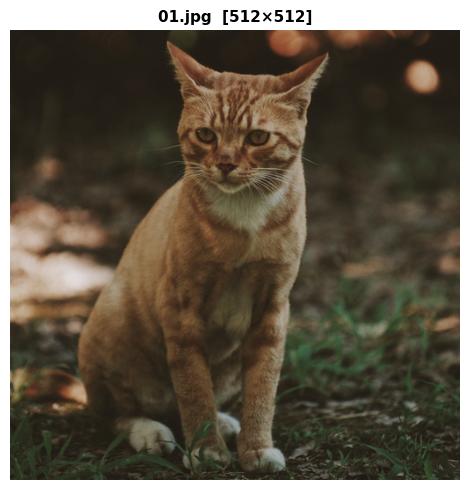

Loaded: input_data/images_dreambooth/cat/01.jpg


In [5]:
input_size  = G.getint("input_size")
source_image = load_image_rgb(IMAGE_PATH, size=(input_size, input_size))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(source_image)
ax.set_title(f"{Path(IMAGE_PATH).name}  [{input_size}×{input_size}]", fontsize=11, weight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Loaded: {IMAGE_PATH}")

---
## Step 3: DDIM Inversion

Runs the reverse diffusion process to obtain per-timestep latents and cross-attention maps for the subject tokens.

In [6]:
# Build inversion prompt according to pass1 mode
if P1["inversion_prompt_mode"] == "empty":
    inversion_prompt = ""
else:  # "auto"
    inversion_prompt = f"photo of a {SUBJECT_DESCRIPTION}"

print(f"Inversion prompt : {inversion_prompt!r}")
print(f"Target tokens    : {TARGET_TOKENS}")
print(f"Steps            : {G['num_inference_steps']}  |  invert_frac: {P1['invert_frac']}")
print(f"Guidance scale   : {P1['inversion_guidance_scale']}")
print()

inv = ddim_invert_store(
    pipe=pipe,
    image=source_image,
    prompt=inversion_prompt,
    tokens=TARGET_TOKENS,
    num_inference_steps=G.getint("num_inference_steps"),
    invert_frac=P1.getfloat("invert_frac"),
    guidance_scale=P1.getfloat("inversion_guidance_scale"),
    input_size=input_size,
    attention_res=G.getint("attention_res"),
    allowed_places=_parse_tuple_of_strings(G["allowed_places"]),
    capture_attention=True,
    allow_missing_token=True,
    multi_token_merge=G["multi_token_merge"],
)

n_latents = len(inv["latents_all"])
n_attns   = sum(1 for _, a in inv["attns_all"] if a is not None)
print(f"Inversion done.")
print(f"  Stored latents  : {n_latents} steps")
print(f"  Attention maps  : {n_attns}/{n_latents} steps captured")

Inversion prompt : 'photo of a beige cat'
Target tokens    : ['cat']
Steps            : 50  |  invert_frac: 1.0
Guidance scale   : 1.0

Inversion done.
  Stored latents  : 50 steps
  Attention maps  : 50/50 steps captured


---
## Step 4: Base Mask

Builds the subject mask from the inversion attention maps (or SAM) and visualises it:

| Panel | Description |
|-------|-------------|
| **Original** | Input image |
| **Raw attention avg** | Average cross-attention map over the configured step range |
| **Soft mask** | After Otsu thresholding → sigmoid sharpening → blur |
| **Binary mask overlay** | Final binary mask painted over the original image |

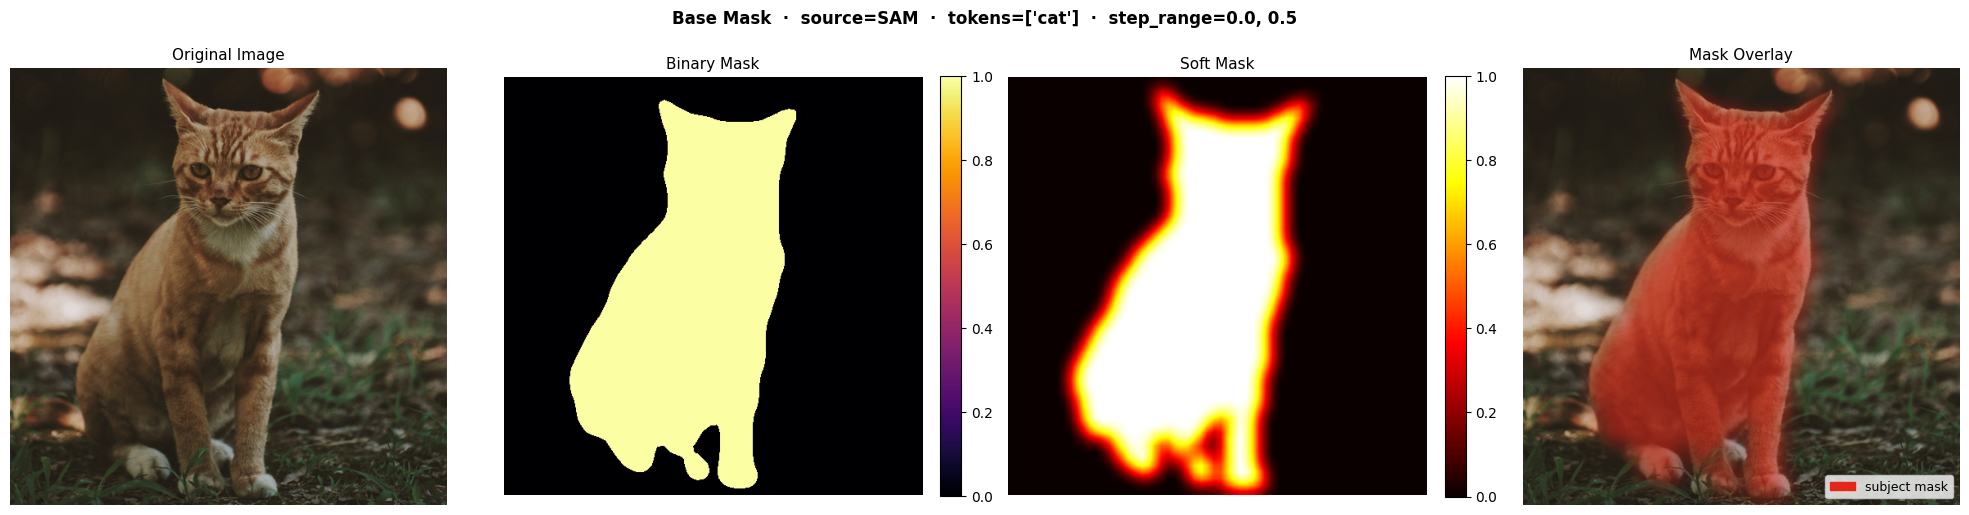

Mask coverage : 30.3%  |  saved → output_notebook/base_mask.png


In [13]:
# ── Helpers ────────────────────────────────────────────────────────
def _t2np(tensor, hw=None):
    """Tensor (any shape with leading 1×1 or 2D) → numpy float32 H×W."""
    t = tensor.detach().float().cpu()
    while t.ndim > 2:
        t = t[0]
    if hw is not None:
        t = F.interpolate(t[None, None], size=hw, mode="bilinear", align_corners=False)[0, 0]
    return t.numpy()

def _overlay(img_np, mask_np, color=(0.9, 0.15, 0.1), alpha=0.55):
    """Alpha-blend a soft/binary mask as a coloured tint on top of an RGB image."""
    out = img_np.astype(np.float32) / 255.0
    for c, v in enumerate(color):
        out[..., c] = (1 - alpha * mask_np) * out[..., c] + alpha * mask_np * v
    return np.clip(out, 0, 1)

# ── Build the base mask (same logic as the editing pass) ───────────
latent_hw = (input_size // 8, input_size // 8)   # e.g. 64×64 for 512-px input
display_hw = (input_size, input_size)

have_attns = any(a is not None for _, a in inv["attns_all"])

if _base_mask_source == "sam" and grounded_sam is not None:
    from sd_editing.sam_mask import grounded_sam_mask
    main_mask_t = grounded_sam_mask(source_image, TARGET_TOKENS, grounded_sam, latent_hw)
    base_soft_np = _t2np(main_mask_t, hw=display_hw)
    main_mask_np = (base_soft_np > 0.5).astype(np.float32)
    base_raw_np  = main_mask_np
    raw_title    = "Binary Mask"
    mask_label   = "SAM"
elif have_attns:
    inv_maps = [a for (_, a) in inv["attns_all"]]
    base_raw_t, base_soft_t, main_mask_t = build_base_mask_from_inversion_attn(
        inv_maps,
        step_frac_range=_parse_float_pair(G["base_mask_step_range"]),
        target_size=latent_hw,
        invert=G.getboolean("invert_mask"),
        erode_radius=P1.getint("base_mask_erode_radius"),
    )
    base_raw_np  = _t2np(base_raw_t[None, None], hw=display_hw)
    base_soft_np = _t2np(base_soft_t, hw=display_hw)
    main_mask_np = _t2np(main_mask_t, hw=display_hw)
    raw_title    = "Raw Attention Avg"
    mask_label   = "Attention"
else:
    print("[WARN] No attention maps and SAM not active — mask is empty.")
    base_raw_np = base_soft_np = main_mask_np = np.zeros((input_size, input_size), dtype=np.float32)
    raw_title   = "Raw Mask"
    mask_label  = "None"

image_np = np.array(source_image)

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f"Base Mask  ·  source={mask_label}  ·  tokens={TARGET_TOKENS}  ·  "
    f"step_range={G['base_mask_step_range'].strip()}",
    fontsize=12, weight="bold", y=1.02,
)

axes[0].imshow(image_np)
axes[0].set_title("Original Image", fontsize=11)

im1 = axes[1].imshow(base_raw_np, cmap="inferno", vmin=0, vmax=1)
axes[1].set_title(raw_title, fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(base_soft_np, cmap="hot", vmin=0, vmax=1)
axes[2].set_title("Soft Mask", fontsize=11)
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

overlay_np = _overlay(image_np, base_soft_np)
axes[3].imshow(overlay_np)
axes[3].set_title("Mask Overlay", fontsize=11)
from matplotlib.patches import Patch
axes[3].legend(handles=[Patch(color=(0.9, 0.15, 0.1), label="subject mask")],
               loc="lower right", fontsize=9, framealpha=0.8)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/base_mask.png", dpi=150, bbox_inches="tight")
plt.show()

coverage = float(main_mask_np.mean()) * 100
print(f"Mask coverage : {coverage:.1f}%  |  saved → {OUTPUT_DIR}/base_mask.png")

---
## Step 5: Edit — Pass 1

Runs the editing denoising pass with inversion latent blending.

Edit prompt         : 'a photo of a beige cat sitting in the snow'
Guidance scale      : 7.5
Eta                 : 1.0
Alpha               : 1.0
Alpha end           : 0.25
Noise beta          : 0.75



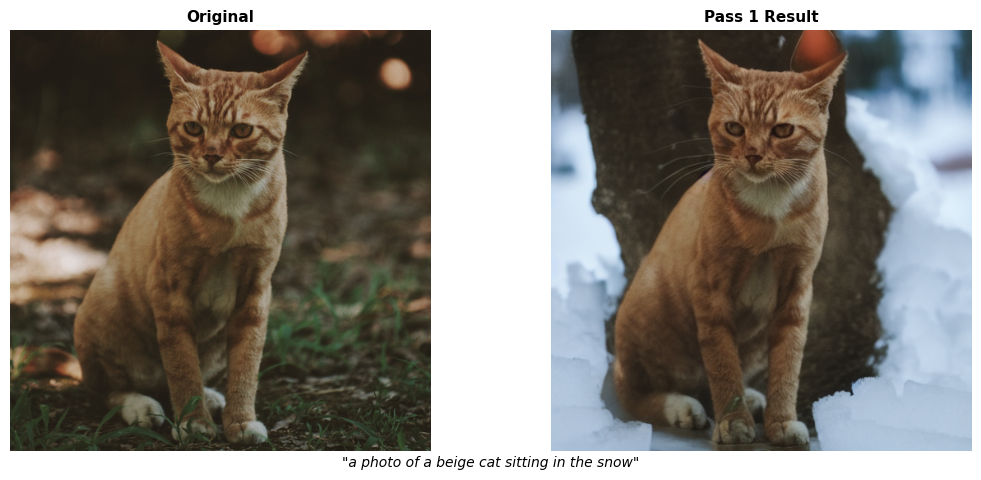

Saved → output_notebook/pass1.png


In [8]:
# Resolve overrides
_guidance       = OVERRIDE.get("guidance_scale",          P1.getfloat("guidance_scale"))
_eta            = OVERRIDE.get("eta",                      P1.getfloat("eta"))
_alpha          = OVERRIDE.get("transmission_alpha",       P1.getfloat("transmission_alpha"))
_alpha_end      = OVERRIDE.get("transmission_alpha_end",   P1.getfloat("transmission_alpha_end"))
_noise_beta     = OVERRIDE.get("initial_noise_beta",       P1.getfloat("initial_noise_beta"))

print(f"Edit prompt         : {EDIT_PROMPT!r}")
print(f"Guidance scale      : {_guidance}")
print(f"Eta                 : {_eta}")
print(f"Alpha               : {_alpha}")
print(f"Alpha end           : {_alpha_end}")
print(f"Noise beta          : {_noise_beta}")
print()

edited_pass1 = reconstruct_ddim_with_attention_restoration(
    pipe=pipe,
    latents_all=inv["latents_all"],
    attns_all=inv["attns_all"],
    prompt=EDIT_PROMPT,
    tokens=TARGET_TOKENS,
    guidance_scale=_guidance,
    num_inference_steps=G.getint("num_inference_steps"),
    input_size=input_size,
    attention_res=G.getint("attention_res"),
    allowed_places=_parse_tuple_of_strings(G["allowed_places"]),
    base_mask_step_range=_parse_float_pair(G["base_mask_step_range"]),
    invert_mask=G.getboolean("invert_mask"),
    base_mask_erode_radius=P1.getint("base_mask_erode_radius"),
    eta=_eta,
    multi_token_merge=G["multi_token_merge"],
    base_mask_source=_base_mask_source,
    source_image=source_image,
    grounded_sam=grounded_sam,
    use_inversion_attention_transmission=P1.getboolean("use_inversion_attention_transmission"),
    use_reconstruction_attention_transmission=P1.getboolean("use_reconstruction_attention_transmission"),
    transmission_alpha=_alpha,
    transmission_alpha_end=_alpha_end,
    initial_noise_beta=_noise_beta,
    recon_dilate_radius=P1.getint("recon_dilate_radius"),
    transition_gap_radius=P1.getint("transition_gap_radius"),
    alpha_decay_start=P1.getfloat("alpha_decay_start"),
    recon_alpha_decay=P1.getboolean("recon_alpha_decay"),
    recon_attn_start_frac=P1.getfloat("recon_attn_start_frac"),
)

edited_pass1.save(f"{OUTPUT_DIR}/pass1.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(source_image);  axes[0].set_title("Original",       fontsize=11, weight="bold")
axes[1].imshow(edited_pass1);  axes[1].set_title("Pass 1 Result",  fontsize=11, weight="bold")
for ax in axes:
    ax.axis("off")
fig.suptitle(f'"{EDIT_PROMPT}"', fontsize=10, style="italic", y=0.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pass1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/pass1.png")

---
## Step 6: Polish — Pass 2

Re-inverts the Pass-1 result and runs a refinement pass.  
Skipped automatically when `pass2.enabled = false` in `config.ini`.

In [15]:
_run_pass2 = P2.getboolean("enabled")
edited_pass2 = None

if not _run_pass2:
    print("Pass 2 disabled in config.ini — skipping.")
else:
    # ── Resolve prompts for pass 2 (mirrors batch.py resolve_prompt_mode) ────
    _p2_inv_mode   = P2.get("inversion_prompt_mode", "empty")
    _p2_recon_mode = P2.get("reconstruction_prompt_mode", "edit")
    _p2_inv_prompt   = EDIT_PROMPT if _p2_inv_mode   == "edit" else ""
    _p2_recon_prompt = EDIT_PROMPT if _p2_recon_mode == "edit" else ""

    print(f"Pass 2 inversion prompt  : {_p2_inv_prompt!r}")
    print(f"Pass 2 recon prompt      : {_p2_recon_prompt!r}")
    print(f"invert_frac              : {P2['invert_frac']}")
    print()

    # Invert the pass-1 result
    polish_inv = ddim_invert_store(
        pipe=pipe,
        image=edited_pass1,
        prompt=_p2_inv_prompt,
        tokens=TARGET_TOKENS,
        num_inference_steps=G.getint("num_inference_steps"),
        invert_frac=P2.getfloat("invert_frac"),
        guidance_scale=P2.getfloat("inversion_guidance_scale"),
        input_size=input_size,
        attention_res=G.getint("attention_res"),
        allowed_places=_parse_tuple_of_strings(G["allowed_places"]),
        capture_attention=P2.getboolean("use_inversion_attention_transmission"),
        allow_missing_token=True,
        multi_token_merge=G["multi_token_merge"],
    )

    # Polish edit — uses polish_inv latents but ORIGINAL inv attns for base mask
    edited_pass2 = reconstruct_ddim_with_attention_restoration(
        pipe=pipe,
        latents_all=polish_inv["latents_all"],
        attns_all=inv["attns_all"],          # original inversion attention → base mask
        prompt=_p2_recon_prompt,
        tokens=TARGET_TOKENS,
        guidance_scale=P2.getfloat("guidance_scale"),
        num_inference_steps=G.getint("num_inference_steps"),
        input_size=input_size,
        attention_res=G.getint("attention_res"),
        allowed_places=_parse_tuple_of_strings(G["allowed_places"]),
        base_mask_step_range=_parse_float_pair(G["base_mask_step_range"]),
        invert_mask=G.getboolean("invert_mask"),
        base_mask_erode_radius=P2.getint("base_mask_erode_radius"),
        eta=P2.getfloat("eta"),
        multi_token_merge=G["multi_token_merge"],
        base_mask_source=_base_mask_source,
        source_image=source_image,
        grounded_sam=grounded_sam,
        use_inversion_attention_transmission=P2.getboolean("use_inversion_attention_transmission"),
        use_reconstruction_attention_transmission=P2.getboolean("use_reconstruction_attention_transmission"),
        transmission_alpha=P2.getfloat("transmission_alpha"),
        transmission_alpha_end=P2.getfloat("transmission_alpha_end"),
        initial_noise_beta=P2.getfloat("initial_noise_beta"),
        recon_dilate_radius=P2.getint("recon_dilate_radius"),
        transition_gap_radius=P2.getint("transition_gap_radius"),
        alpha_decay_start=P2.getfloat("alpha_decay_start"),
        recon_alpha_decay=P2.getboolean("recon_alpha_decay"),
        recon_attn_start_frac=P2.getfloat("recon_attn_start_frac"),
    )

    edited_pass2.save(f"{OUTPUT_DIR}/pass2_polish.png")
    print(f"Saved → {OUTPUT_DIR}/pass2_polish.png")

Pass 2 inversion prompt  : ''
Pass 2 recon prompt      : 'a photo of a beige cat sitting in the snow'
invert_frac              : 0.5

Saved → output_notebook/pass2_polish.png


---
## Step 7: Final Comparison

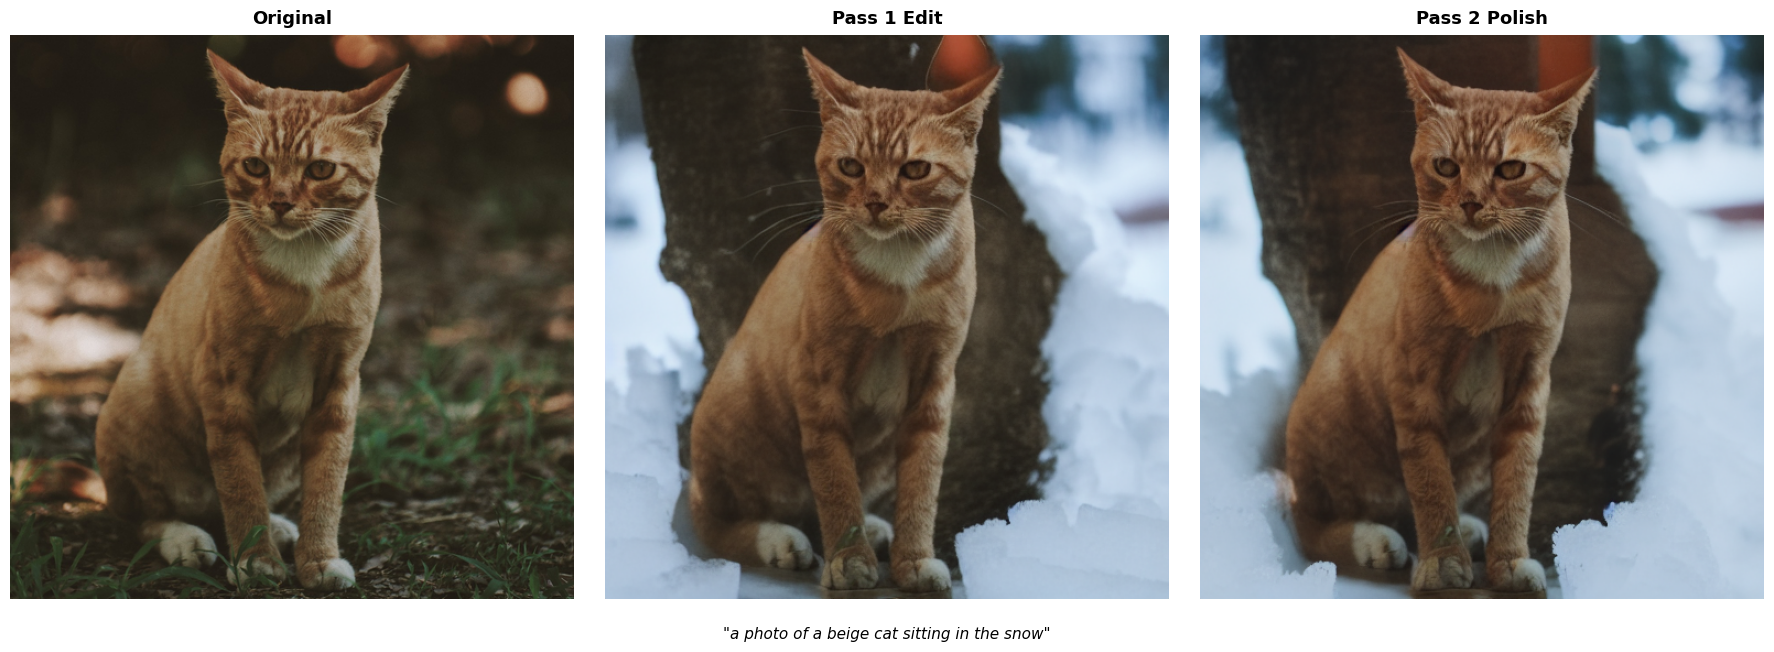

Comparison saved → output_notebook/comparison.png


In [16]:
panels = [("Original", source_image), ("Pass 1 Edit", edited_pass1)]
if edited_pass2 is not None:
    panels.append(("Pass 2 Polish", edited_pass2))

n = len(panels)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6.5))
if n == 1:
    axes = [axes]

for ax, (title, img) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=13, weight="bold", pad=8)
    ax.axis("off")

fig.suptitle(f'"{EDIT_PROMPT}"', fontsize=11, style="italic", y=0.02)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f"{OUTPUT_DIR}/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Comparison saved → {OUTPUT_DIR}/comparison.png")